# **# LABORATORIO 1 - Luciana Carabaguiaz, Diego Diaz, Julián Maroto, Santiago Volio**

## Laboratorio 1
Aquí van retos prácticos para que deben resolver en código, pueden tener asistencia de IA.

Piensa en Python + Colab y la IA se use como copiloto (explicación de lo que no entiendes, depuración de errores y hasta mejoras), no como “copiar/pegar sin entender”.

## Reto 1 — “¿Quién es el más parecido?” (Distancia euclidiana)

Meta: calcular qué cliente está más cerca de un “cliente objetivo”.

Tareas:

* Calcular distancia euclidiana de cada cliente al objetivo.
* Ordenar de menor a mayor distancia.
* Imprimir el “top 2” más similares.
* Argumenten en su grupo por qué creen que es el más cercano
* Extra (bonus): que el código devuelva también el nombre del cliente más cercano.


In [ ]:
import numpy as np

clientes = {
  "Cliente A": np.array([25, 500, 0.20]),
  "Cliente B": np.array([40, 800, 0.90]),
  "Cliente C": np.array([28, 520, 0.25]),
  "Cliente D": np.array([60, 1200, 0.40])
}
objetivo = np.array([27, 510, 0.22])

distancias_euclidianas = {}
for nombre_cliente, datos_cliente in clientes.items():
    distancia = np.linalg.norm(datos_cliente - objetivo)
    distancias_euclidianas[nombre_cliente] = distancia

clientes_ordenados = sorted(distancias_euclidianas.items(), key=lambda item: item[1])
print("Distancias euclidianas: ")

# Distancia EUCLIDIANA
print(distancias_euclidianas)
print()

# Menor a mayor distancia
distancias_ordenadas = sorted(distancias_euclidianas.items(), key=lambda x: x[1])
print("Distancias de cada cliente en orden:")
print(distancias_ordenadas)
print()

# Imprimir el top 2 más similares
print("Top 2 clientes más similares (distancia euclidiana):")
for i, (nombre, distancia) in enumerate(clientes_ordenados[:2]):
    print(f"{i+1}. {nombre}: {distancia:.2f}")
print()

# Extra: nombre del cliente más cercano
cliente_mas_cercano_nombre = clientes_ordenados[0][0]
print(f"\nEl cliente más cercano es: {cliente_mas_cercano_nombre}")



Distancias euclidianas: 
{'Cliente A': np.float64(10.198058638780227), 'Cliente B': np.float64(290.29202951510746), 'Cliente C': np.float64(10.0499203976947), 'Cliente D': np.float64(690.788703150247)}

Distancias de cada cliente en orden:
[('Cliente C', np.float64(10.0499203976947)), ('Cliente A', np.float64(10.198058638780227)), ('Cliente B', np.float64(290.29202951510746)), ('Cliente D', np.float64(690.788703150247))]

Top 2 clientes más similares (distancia euclidiana):
1. Cliente C: 10.05
2. Cliente A: 10.20


El cliente más cercano es: Cliente C


## Reto 2 — “Pitágoras te engañó” (Normalización y cambio de ganador)

Meta: demostrar que sin escalar, una variable domina la distancia.

Tareas:
* Repetir el Reto 1 con el nuevo dataset
* Aplicar StandardScaler (o MinMaxScaler) a todos los vectores (clientes + objetivo).
* Recalcular distancias y ver si cambia el ganador.
* ¿El ganador cambió? Argumente con sus compañeros por que sí o por qué no

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# (1) Datos
objetivo = np.array([50, 5000, 0.5])

clientes = {
    "Cliente A": np.array([0,    5000, 10.0]),
    "Cliente B": np.array([50,   5200, 0.5]),
    "Cliente C": np.array([50,      0, 0.5]),
    "Cliente D": np.array([50,  10000, 0.5])
}

# --- Reto 2: Parte 1 - Repetir Reto 1 sin escalar ---
distancias_euclidianas_sin_escalar = {}
for nombre_cliente, datos_cliente in clientes.items():
    distancia = np.linalg.norm(datos_cliente - objetivo)
    distancias_euclidianas_sin_escalar[nombre_cliente] = distancia

clientes_ordenados_sin_escalar = sorted(distancias_euclidianas_sin_escalar.items(), key=lambda item: item[1])

print("--- SIN ESCALADO ---")
print("Distancias euclidianas (sin escalar):", distancias_euclidianas_sin_escalar, "\n")
print("Distancias en orden (sin escalar):", clientes_ordenados_sin_escalar, "\n")

print("Top 2 clientes más similares (sin escalar):")
for i, (nombre, distancia) in enumerate(clientes_ordenados_sin_escalar[:2], start=1):
    print(f"{i}. {nombre}: {distancia:.4f}")

ganador_sin = clientes_ordenados_sin_escalar[0][0]
print(f"\nCliente más cercano (sin escalar): {ganador_sin}\n")

# --- Reto 2: Parte 2 - Aplicar StandardScaler y recalcular ---
# Escalado

scaler = StandardScaler()
nombres = list(clientes.keys())
X_clientes = np.vstack([clientes[n] for n in nombres])        # shape (4,3)
X_total = np.vstack([X_clientes, objetivo])                   # shape (5,3)
X_total_scaled = scaler.fit_transform(X_total)

# Separar de vuelta: clientes escalados y objetivo escalado
X_clientes_scaled = X_total_scaled[:-1, :]
objetivo_scaled = X_total_scaled[-1, :]

# Reconstruimos dict de clientes escalados
clientes_scaled = {nombres[i]: X_clientes_scaled[i] for i in range(len(nombres))}

# (4) Distancias
distancias_scaled = {}
for nombre_cliente, vec_scaled in clientes_scaled.items():
    distancias_scaled[nombre_cliente] = np.linalg.norm(vec_scaled - objetivo_scaled)

clientes_ordenados_scaled = sorted(distancias_scaled.items(), key=lambda item: item[1])

print("--- CON ESCALADO: (StandardScaler) ---")
print("Distancias euclidianas (escaladas):", distancias_scaled, "\n")
print("Distancias en orden (escaladas):", clientes_ordenados_scaled, "\n")

print("Top 2 clientes más similares (escalado):")
for i, (nombre, distancia) in enumerate(clientes_ordenados_scaled[:2], start=1):
    print(f"{i}. {nombre}: {distancia:.4f}")

ganador_con = clientes_ordenados_scaled[0][0]
print(f"\nCliente más cercano (escalado): {ganador_con}")

--- SIN ESCALADO ---
Distancias euclidianas (sin escalar): {'Cliente A': np.float64(50.89449872039217), 'Cliente B': np.float64(200.0), 'Cliente C': np.float64(5000.0), 'Cliente D': np.float64(5000.0)} 

Distancias en orden (sin escalar): [('Cliente A', np.float64(50.89449872039217)), ('Cliente B', np.float64(200.0)), ('Cliente C', np.float64(5000.0)), ('Cliente D', np.float64(5000.0))] 

Top 2 clientes más similares (sin escalar):
1. Cliente A: 50.8945
2. Cliente B: 200.0000

Cliente más cercano (sin escalar): Cliente A

--- CON ESCALADO: (StandardScaler) ---
Distancias euclidianas (escaladas): {'Cliente A': np.float64(3.5355339059327373), 'Cliente B': np.float64(0.0632253243356813), 'Cliente C': np.float64(1.5806331083920326), 'Cliente D': np.float64(1.5806331083920326)} 

Distancias en orden (escaladas): [('Cliente B', np.float64(0.0632253243356813)), ('Cliente C', np.float64(1.5806331083920326)), ('Cliente D', np.float64(1.5806331083920326)), ('Cliente A', np.float64(3.535533905932

## Reto 3 — “Parecido por dirección” (Similitud coseno)

Meta: comparar euclidiana vs coseno y discutir cuándo conviene cada una.

Tareas:
Parte 1:
* Calcula la distancia euclidiana entre el usuario y cada item.
* Ordena los items de menor a mayor distancia.
* Indica cuál es el item más cercano al usuario.

Parte 2:
* Calcula la similitud coseno entre el usuario y cada item.
* Ordena los items de mayor a menor similitud.
* Indica cuál es el item más similar según coseno.

Parte 3:
* Grafica al usuario y a los items como puntos en el plano. (Graficar punto 1)

* Etiqueta cada punto.

Observa el gráfico y responde:
¿Cuál punto está más cerca del usuario?
¿Esta vista explica el ranking por distancia?

Parte 4:
* Grafica al usuario y a los items como vectores desde el origen. (Graficar punto 2)
* Observa la dirección de cada vector.

Observa el gráfico y responde:
¿Qué vectores están más alineados con el usuario?
¿Esta vista explica el ranking por coseno?


Parte 5: Relfexión:
* ¿Por qué el mismo dato puede verse como punto o como vector,
    y cómo cambia la historia según la métrica que usemos?
*9Qué mide exactamente la distancia euclidiana y el coseno, y por qué cambia el resultado?

In [ ]:
import numpy as np
# Preferencias del usuario (patrón claro)
usuario = np.array([8, 2, 1])  # mucho rock, poco pop, casi nada jazz

items = {
    "Rock":  np.array([9, 2, 1]),     # MUY cerca y bien alineado
    "Metal":  np.array([80, 20, 10]),  # MISMA dirección, magnitud enorme
    "Pop":   np.array([2, 8, 3]),     # cerca pero dirección distinta
    "Jazz":  np.array([1, 2, 9])      # cerca pero casi opuesto
}
distancias = {}

Codigo resuelto


In [ ]:
distancias_euclidianas = {}
for nombre_item, vector_item in items.items():
    distancia = np.linalg.norm(vector_item - usuario)
    distancias_euclidianas[nombre_item] = distancia

# Ordenar de menor a mayor distancia
ranking_euclid_recalc = sorted(distancias_euclidianas.items(), key=lambda item: item[1])

print("\n--- Recálculo de Distancia Euclidiana ---")
print("Distancias euclidianas (menor es más parecido):")
for nombre, d in ranking_euclid_recalc:
    print(f"  {nombre:>5}: {d:.4f}")

item_mas_cercano = ranking_euclid_recalc[0][0]
print(f"\nEl ítem más cercano por distancia euclidiana es: {item_mas_cercano}")


--- Recálculo de Distancia Euclidiana ---
Distancias euclidianas (menor es más parecido):
   Rock: 1.0000
    Pop: 8.7178
   Jazz: 10.6301
  Metal: 74.7596

El ítem más cercano por distancia euclidiana es: Rock


In [ ]:
import numpy as np

# Preferencias del usuario (patrón claro)
usuario = np.array([8, 2, 1])  # mucho rock, poco pop, casi nada jazz

items = {
    "Rock":  np.array([9, 2, 1]),      # MUY cerca y bien alineado
    "Metal": np.array([80, 20, 10]),   # MISMA dirección, magnitud enorme
    "Pop":   np.array([2, 8, 3]),      # dirección distinta
    "Jazz":  np.array([1, 2, 9])       # dirección muy distinta
}

distancias_euclidianas = {}
for nombre_item, vector_item in items.items():
    distancia = np.linalg.norm(vector_item - usuario)
    distancias_euclidianas[nombre_item] = distancia

# Ordenar de menor a mayor distancia
ranking_euclid_recalc = sorted(distancias_euclidianas.items(), key=lambda item: item[1])

print("\n--- Recálculo de Distancia Euclidiana ---")
print("Distancias euclidianas (menor es más parecido):")
for nombre, d in ranking_euclid_recalc:
    print(f"  {nombre:>5}: {d:.4f}")

item_mas_cercano = ranking_euclid_recalc[0][0]
print(f"\nEl ítem más cercano por distancia euclidiana es: {item_mas_cercano}")


--- Recálculo de Distancia Euclidiana ---
Distancias euclidianas (menor es más parecido):
   Rock: 1.0000
    Pop: 8.7178
   Jazz: 10.6301
  Metal: 74.7596

El ítem más cercano por distancia euclidiana es: Rock


In [ ]:
def similitud_coseno(a: np.ndarray, b: np.ndarray) -> float:
    # cos(a,b) = (a·b) / (||a|| ||b||)
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

cosenos_recalc = {}
for nombre_item, vector_item in items.items():
    cosenos_recalc[nombre_item] = similitud_coseno(vector_item, usuario)

# Ordenar de mayor a menor similitud (más cercano)
ranking_cos_recalc = sorted(cosenos_recalc.items(), key=lambda item: item[1], reverse=True)

print("\n--- Recálculo de Similitud Coseno ---")
print("Similitudes coseno (mayor es más parecido):")
for nombre, c in ranking_cos_recalc:
    print(f"  {nombre:>5}: {c:.6f}")

item_mas_similar = ranking_cos_recalc[0][0]
print(f"\nEl ítem más similar por coseno es: {item_mas_similar}")


--- Recálculo de Similitud Coseno ---
Similitudes coseno (mayor es más parecido):
  Metal: 1.000000
   Rock: 0.999579
    Pop: 0.480173
   Jazz: 0.272612

El ítem más similar por coseno es: Metal


In [ ]:
def similitud_coseno(a: np.ndarray, b: np.ndarray) -> float:
    # cos(a,b) = (a·b) / (||a|| ||b||)
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

cosenos_recalc = {}
for nombre_item, vector_item in items.items():
    cosenos_recalc[nombre_item] = similitud_coseno(vector_item, usuario)

# Ordenar de mayor a menor similitud (más cercano)
ranking_cos_recalc = sorted(cosenos_recalc.items(), key=lambda item: item[1], reverse=True)

print("\n--- Recálculo de Similitud Coseno ---")
print("Similitudes coseno (mayor es más parecido):")
for nombre, c in ranking_cos_recalc:
    print(f"  {nombre:>5}: {c:.6f}")

item_mas_similar = ranking_cos_recalc[0][0]
print(f"\nEl ítem más similar por coseno es: {item_mas_similar}")


--- Recálculo de Similitud Coseno ---
Similitudes coseno (mayor es más parecido):
  Metal: 1.000000
   Rock: 0.999579
    Pop: 0.480173
   Jazz: 0.272612

El ítem más similar por coseno es: Metal


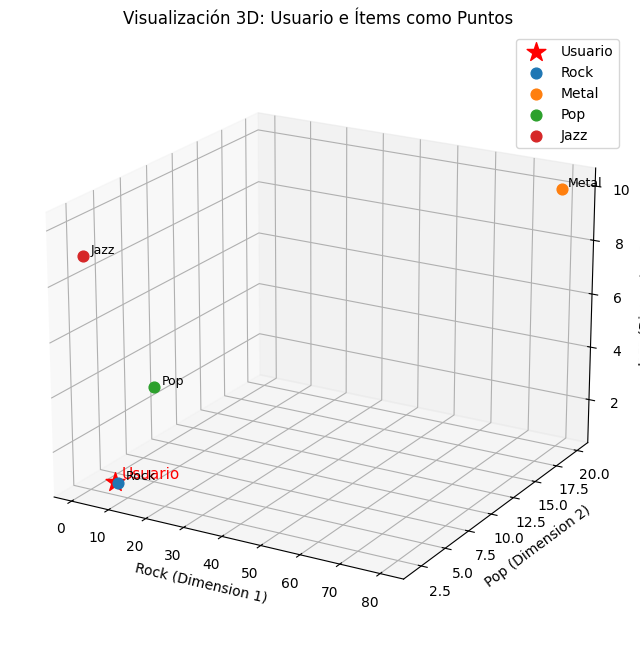

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Prepare data for 3D plotting
user_3d = usuario
items_3d = {name: vector for name, vector in items.items()}

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Set a consistent view angle
ax.view_init(elev=20, azim=-60)
ax.grid(True) # Ensure grid is visible

# Plot user as a distinct point with adjusted size and text offset
ax.scatter(user_3d[0], user_3d[1], user_3d[2], marker='*', s=200, color='red', label='Usuario')
ax.text(user_3d[0] + 0.5, user_3d[1] + 0.5, user_3d[2], 'Usuario', color='red', fontsize=11)

# Plot items with adjusted size and text offset
for name, vec in items_3d.items():
    ax.scatter(vec[0], vec[1], vec[2], s=60, label=name)
    ax.text(vec[0] + 0.5, vec[1] + 0.5, vec[2], name, fontsize=9)

ax.set_xlabel('Rock (Dimension 1)')
ax.set_ylabel('Pop (Dimension 2)')
ax.set_zlabel('Jazz (Dimension 3)')
ax.set_title('Visualización 3D: Usuario e Ítems como Puntos')
ax.legend()
plt.show()

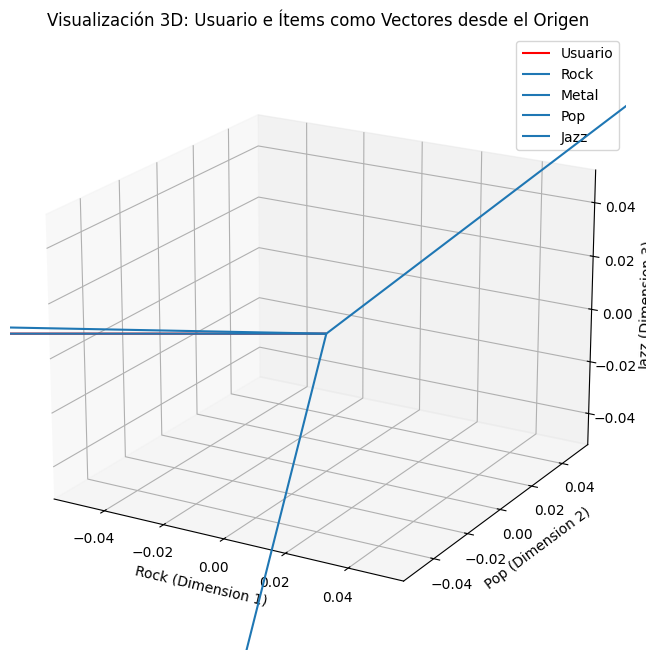

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Set a consistent view angle
ax.view_init(elev=20, azim=-60)
ax.grid(True) # Ensure grid is visible

# Plot user vector with adjusted text offset
ax.quiver(0, 0, 0, usuario[0], usuario[1], usuario[2], color='red', arrow_length_ratio=0.05, label='Usuario')
ax.text(usuario[0] + 0.5, usuario[1] + 0.5, usuario[2], 'Usuario', color='red', fontsize=12)

# Plot item vectors with adjusted text offset
for name, vec in items.items():
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], arrow_length_ratio=0.05, label=name)
    ax.text(vec[0] + 0.5, vec[1] + 0.5, vec[2], name, fontsize=10)

ax.set_xlabel('Rock (Dimension 1)')
ax.set_ylabel('Pop (Dimension 2)')
ax.set_zlabel('Jazz (Dimension 3)')
ax.set_title('Visualización 3D: Usuario e Ítems como Vectores desde el Origen')
ax.legend()
plt.show()